In [2]:
from collections import Counter
from importlib import reload
import os
from pathlib import Path
import pickle
from pprint import pprint

os.chdir("/home/lk3591/Documents/code/RawByteClf/src")

import matplotlib.pyplot as plt
from tqdm import tqdm

from data.lab import get_labels

In [3]:
BINS = ["ELF", "Mach-O", "PE"]
EXS = ["name", "category", "label"]

def vt_path_to_bin(p: Path):
    p = p.as_posix().upper()
    if "ELF" in p:
        return "ELF"
    if "MACH" in p:
        return "Mach-O"
    if "WIN" in p:
        return "PE"
    raise RuntimeError(p)

ROOT = Path("/home/lk3591/Documents/datasets")
paths_and_bins = [
    (ROOT / "Sorel/reports/", "PE"),
    (ROOT / "VirusShare/VirusShare_ELF_20140617/reports/", "ELF"),
    (ROOT / "VirusShare/VirusShare_ELF_20190212/reports/", "ELF"),
    (ROOT / "VirusShare/VirusShare_ELF_20200405/reports/", "ELF"),
    (ROOT / "VirusShare/VirusShare_Linux_20160715/reports/", "ELF"),
    (ROOT / "MalwareBazaar/elf/reports", "ELF")
    (ROOT / "MalwareBazaar/macho/reports", "MACHO")
]
paths_and_bins += [
   (p, vt_path_to_bin(p)) for p in (ROOT / "VirusTotal/extracted/").rglob("reports")
]

In [12]:
def get_data(paths_and_bins):
    data = {b : {e : Counter() for e in EXS} for b in BINS}

    pbar = tqdm(paths_and_bins)
    for p, b in pbar:
        report_files = list(p.iterdir())
        pbar.set_description(f"{p.relative_to(ROOT)} {len(report_files)=}")
        
        for e in EXS:
            _labels = get_labels(report_files, extractor=e, logfile="/home/lk3591/Documents/code/RawByteClf/labels.log")
            labels = []
            for l in tqdm(_labels, total=len(report_files)):
                if l is not None:
                    labels.append(l)
            labels = [[l for l, i in label] for label in labels]
            flat_labels = [item for t in labels for item in t]
            print(f"{e=} {len(labels)=} {len(flat_labels)=}")
            data[b][e].update(flat_labels)
    return data
    

In [ ]:
if (path := Path("/home/lk3591/Documents/code/RawByteClf/src/labels.pkl")).exists():
    data = pickle.load(open(path, "rb"))
else:
    data = get_data(paths_and_bins)

In [26]:
data["Mach-O"] = get_data([
    (ROOT / "MalwareBazaar/macho/reports", "Mach-O"),
])["Mach-O"]

for e, d in get_data([(ROOT / "VirusTotal/queried/macho/reports", "Mach-O")])["Mach-O"].items():
    data["Mach-O"][e].update(d)

# for e, d in get_data([(ROOT / "MalwareBazaar/macho/reports", "Mach-O")])["ELF"].items():
#     data["ELF"][e].update(d)


100%|██████████| 74/74 [00:00<00:00, 3920.11it/s]   0%|          | 0/1 [00:00<?, ?it/s]


e='name' len(labels)=68 len(flat_labels)=173


100%|██████████| 74/74 [00:00<00:00, 3971.01it/s]


e='category' len(labels)=69 len(flat_labels)=98


MalwareBazaar/macho/reports len(report_files)=74: 100%|██████████| 1/1 [00:00<00:00, 15.97it/s]


...

e='name' len(labels)=72 len(flat_labels)=176


100%|██████████| 159/159 [00:00<00:00, 4495.56it/s]


e='category' len(labels)=74 len(flat_labels)=109


100%|██████████| 159/159 [00:00<00:00, 4651.20it/s]
VirusTotal/queried/macho/reports len(report_files)=159: 100%|██████████| 1/1 [00:00<00:00,  3.52it/s]

e='label' len(labels)=77 len(flat_labels)=77


In [16]:
data["ELF"]

{'name': Counter({'mare': 32,
          'kaigent': 1,
          'lupper': 31,
          'generica': 5715,
          'uselvj623': 79,
          'tsunami': 1440,
          'gjifg': 120,
          'kaiten': 650,
          'mechbot': 79,
          'gmon': 191,
          'meche': 53,
          'kldhide': 7,
          'tlctf': 2,
          'xkeylogger': 4,
          'portscan': 99,
          'xsun': 1,
          'deliri': 8,
          'expl': 5119,
          'gzid': 1,
          'griz': 1,
          'rootkit': 792,
          'enoket': 25,
          'lotoor': 1304,
          'sirius': 2,
          'flooder': 560,
          'dcom': 38,
          'gwxhi': 18,
          'dcomrpc': 28,
          'ddos': 20741,
          'acpi': 6,
          'kokain': 4,
          'local': 239,
          'shark': 32,
          'scanner': 31,
          'login': 5,
          'lindose': 6,
          'peelf': 6,
          'pelf': 3,
          'uselvj523': 47,
          'matrics': 42,
          'genericrxpk': 9,
      

In [29]:
for b in BINS:
    print(data[b].keys())

dict_keys(['name', 'category', 'label'])
dict_keys(['name', 'category', 'label'])
dict_keys(['name', 'category', 'label'])


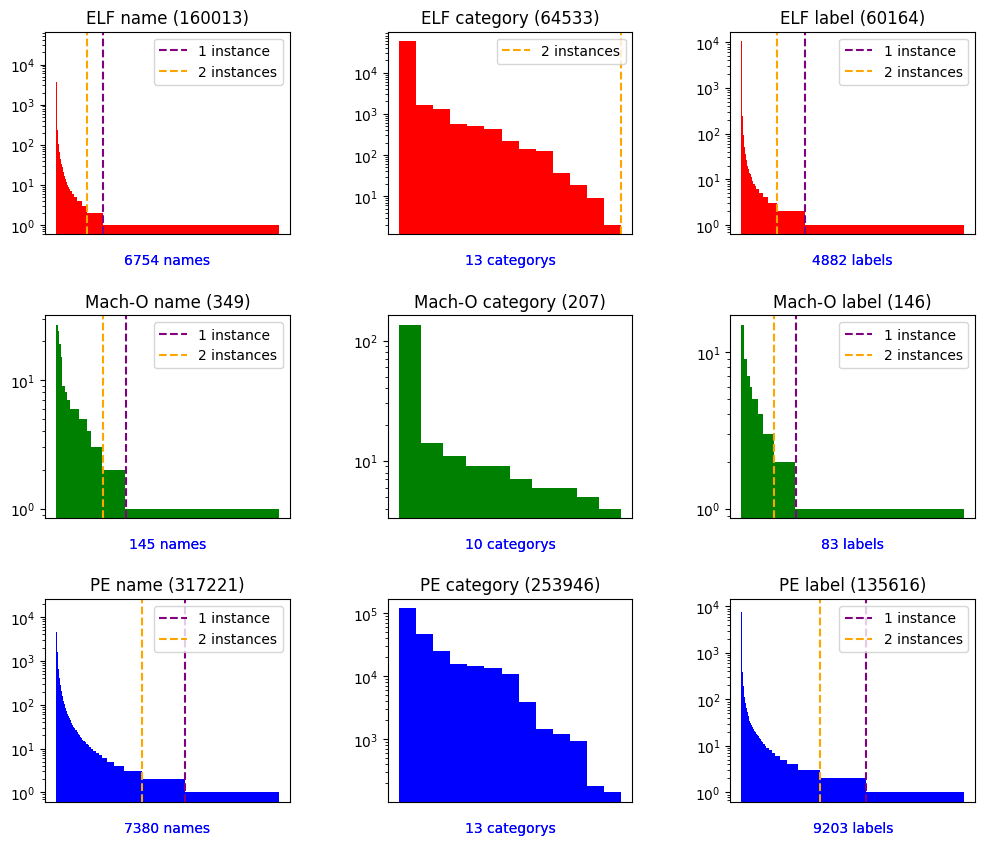

In [27]:
fig, axs = plt.subplots(3, 3, figsize=(12, 10))
plt.subplots_adjust(wspace=0.4, hspace=0.4)

COLORS = {b : c for b, c in zip(BINS, ["red", "green", "blue"])}

for b in BINS:
    for e in EXS:
        c = data[b][e]
        if not c:
            continue
        v_c = sorted(((v, c) for v, c in c.items()), key=lambda x: x[1], reverse=True)
        values, counts = zip(*v_c)
        ax = axs[BINS.index(b), EXS.index(e)]
        
        ax.hist(values, weights=counts, bins=len(set(values)), log=True, color=COLORS[b])
        ax.set_title(f"{b} {e} ({sum(counts)})")
        ax.set_xticks([])
        ax.text(0.5, -0.15, f"{len(set(values))} {e}s", horizontalalignment='center',
            transform=ax.transAxes, fontsize=10, color='blue')
        ax.text(0.5, -0.15, f"{len(set(values))} {e}s", horizontalalignment='center',
            transform=ax.transAxes, fontsize=10, color='blue')


        unique_value, unique_count = None, 0
        thresh, thresh_value, thresh_count = 2, None, 0
        for value, count in c.items():
            if count == 1:
                unique_value = value
                unique_count = count
                break
        for value, count in c.items():
            if count == thresh:
                thresh_value = value
                thresh_count = count
                break
                
        if unique_value is not None:
            ax.axvline(x=unique_value, color='purple', linestyle='--', label=f"1 instance")
        if thresh_value is not None:
            ax.axvline(x=thresh_value, color='orange', linestyle='--', label=f"2 instances")
        if unique_value or thresh_value:
            ax.legend(loc='upper right')

In [24]:
paths_and_bins = [
   (p, vt_path_to_bin(p)) for p in (ROOT / "VirusTotal/extracted/").rglob("reports")
]
for p, b in paths_and_bins:
   report_files = list(p.iterdir())
   labels = list(
      filter(
         lambda l: l is not None,
         get_labels(
            report_files,
            extractor="name",
            logfile="/home/lk3591/Documents/code/RawByteClf/labels.log",
            ),
      )
   )
   print(f"{p=} {e=}, {len(labels)=}")

p=PosixPath('/home/lk3591/Documents/datasets/VirusTotal/extracted/2017-10-20/ELF/reports') e='label', len(labels)=0
p=PosixPath('/home/lk3591/Documents/datasets/VirusTotal/extracted/2017-10-20/Mach-O/reports') e='label', len(labels)=0
p=PosixPath('/home/lk3591/Documents/datasets/VirusTotal/extracted/2017-10-20/Win32_DLL/reports') e='label', len(labels)=0
p=PosixPath('/home/lk3591/Documents/datasets/VirusTotal/extracted/2017-10-20/Win32_EXE/reports') e='label', len(labels)=0
p=PosixPath('/home/lk3591/Documents/datasets/VirusTotal/extracted/2017-11-20/Win32_DLL/reports') e='label', len(labels)=0
p=PosixPath('/home/lk3591/Documents/datasets/VirusTotal/extracted/2017-11-20/Win32_EXE/reports') e='label', len(labels)=0
p=PosixPath('/home/lk3591/Documents/datasets/VirusTotal/extracted/2018-03-14/ELF/reports') e='label', len(labels)=0
p=PosixPath('/home/lk3591/Documents/datasets/VirusTotal/extracted/2018-03-14/Mach-O/reports') e='label', len(labels)=0
p=PosixPath('/home/lk3591/Documents/datase

In [ ]:
get_labels()